# Wafer Fault Detection

---

## 1. Problem Statement

### 1.1 Business Context

In semiconductor manufacturing, wafers are thin slices of semiconductor material used as the substrate for integrated circuits. During the fabrication process, hundreds of sensors continuously monitor various parameters such as temperature, pressure, gas flow, and other environmental conditions. A faulty wafer, if not detected early, can lead to significant financial losses, wasted materials, and delays in the manufacturing pipeline.

The goal of this project is to build a machine learning model that can predict whether a wafer is **faulty or non-faulty** based on the readings from 590 sensors. Early and accurate detection of defective wafers helps reduce waste, improve yield rates, and ensure quality standards are met.

### 1.2 Objective

This is a **binary classification** problem. The target variable **Good/Bad** indicates:
- **-1**: The wafer is non-faulty (Good)
- **+1**: The wafer is faulty (Bad)

### 1.3 Approach

The project follows a structured machine learning pipeline derived from the original project codebase:
1. Data Loading and Consolidation from multiple batch files
2. Exploratory Data Analysis (EDA) with detailed insights
3. Data Preprocessing: missing value imputation (KNN Imputer), removal of zero-variance features
4. KMeans Clustering to segment the data into distinct groups
5. Per-Cluster Model Training: Random Forest and XGBoost with hyperparameter tuning
6. Model Evaluation and Comparison
7. Final consolidated model training and evaluation

### 1.4 Dataset

The training data is spread across multiple CSV batch files. Each file contains wafer records with 590 sensor readings and a target label. After consolidation, the dataset is stored as **wafer_training_data.csv**.

## 2. Importing Libraries

In [3]:
# Core libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

# Preprocessing
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler

# Clustering
from sklearn.cluster import KMeans

# Classification Models
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score, precision_score,
                              recall_score, matthews_corrcoef)
from sklearn.decomposition import PCA

# Set random seed
np.random.seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Data Loading and Consolidation

In [5]:
# Load the consolidated training data
data = pd.read_csv("wafer_training_data.csv")
print("Dataset loaded successfully.")
print("Shape:", data.shape)
print("Number of sensor features:", data.shape[1] - 2)  # Exclude Wafer ID and target

Dataset loaded successfully.
Shape: (1537, 592)
Number of sensor features: 590


In [6]:
# Preview the first few rows
data.head()

,Unnamed: 0,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,...,Sensor-582,Sensor-583,Sensor-584,Sensor-585,Sensor-586,Sensor-587,Sensor-588,Sensor-589,Sensor-590,Good/Bad
0,Wafer-501,3076.81,2158.75,2208.2334,1517.0152,1.0980,100.0,110.1900,0.1247,1.4357,...,64.2405,0.5016,0.0152,0.0040,3.0319,0.0465,0.0299,0.0090,64.2405,-1
1,Wafer-502,2951.62,2511.92,2253.5111,1397.5060,0.9660,100.0,109.7611,0.1210,1.5527,...,0.0000,0.4953,0.0105,0.0037,2.1266,-0.0012,0.0252,0.0081,0.0000,-1
2,Wafer-503,2930.42,2505.17,2235.0556,1302.6607,1.6347,100.0,109.9856,0.1230,1.4588,...,NaN,0.4958,0.0111,0.0033,2.2296,-0.0012,0.0252,0.0081,0.0000,-1
3,Wafer-504,2997.28,2357.99,2141.0667,1236.5212,0.9698,100.0,98.3344,0.1238,1.5973,...,NaN,0.4962,0.0086,0.0024,1.7297,-0.0012,0.0252,0.0081,0.0000,-1
4,Wafer-505,3025.10,2475.18,2235.0556,1302.6607,1.6347,100.0,109.9856,0.1230,1.5525,...,NaN,0.4983,0.0159,0.0041,3.1927,-0.0012,0.0252,0.0081,0.0000,-1


In [7]:
# Preview the last few rows
data.tail()

,Unnamed: 0,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,...,Sensor-582,Sensor-583,Sensor-584,Sensor-585,Sensor-586,Sensor-587,Sensor-588,Sensor-589,Sensor-590,Good/Bad
1532,Wafer-396,3079.17,2405.56,2217.3777,1425.1041,1.7585,100.0,106.2556,0.1200,1.4794,...,31.3771,0.5080,0.0139,0.0039,2.7328,0.0234,0.0073,0.0024,31.3771,-1
1533,Wafer-397,2911.37,2541.21,2207.8111,1202.4520,1.6219,100.0,108.7689,0.1212,1.5322,...,NaN,NaN,NaN,NaN,NaN,0.0234,0.0073,0.0024,31.3771,-1
1534,Wafer-398,3085.57,2364.78,2178.6889,1657.3518,1.6603,100.0,100.8022,0.1229,1.4945,...,109.5996,0.4986,0.0147,0.0038,2.9493,0.0142,0.0156,0.0044,109.5996,-1
1535,Wafer-399,3053.49,2457.08,2172.5333,1351.9648,1.6377,100.0,103.8800,0.1243,1.5680,...,NaN,0.4981,0.0132,0.0035,2.6491,0.0142,0.0156,0.0044,109.5996,-1
1536,Wafer-400,3120.68,2396.40,2177.0222,1448.8499,1.5565,100.0,103.2567,0.1232,1.4920,...,NaN,0.4975,0.0140,0.0036,2.8098,0.0142,0.0156,0.0044,109.5996,-1


## 4. Initial Data Exploration

### 4.1 Data Structure

In [10]:
# Data types and non-null counts
data.info(verbose=False)
print()
print("Column data types summary:")
print(data.dtypes.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1537 entries, 0 to 1536
Columns: 592 entries, Unnamed: 0 to Good/Bad
dtypes: float64(590), int64(1), object(1)
memory usage: 6.9+ MB

Column data types summary:
float64    590
object       1
int64        1
Name: count, dtype: int64


In [11]:
# Basic statistics for a subset of sensor columns
data.iloc[:, 1:11].describe()

,Sensor-1,Sensor-2,Sensor-3,Sensor-4,Sensor-5,Sensor-6,Sensor-7,Sensor-8,Sensor-9,Sensor-10
count,1531.000000,1530.000000,1523.000000,1523.000000,1523.000000,1523.0,1523.000000,1528.000000,1535.000000,1535.000000
mean,3015.024193,2495.483771,2200.370187,1400.184797,4.255665,100.0,101.062428,0.121817,1.461905,-0.000798
std,73.908774,80.495576,29.461460,443.937101,56.906664,0.0,6.267841,0.009045,0.074078,0.015020
min,2743.240000,2158.750000,2060.660000,0.000000,0.681500,100.0,82.131100,0.000000,1.191000,-0.053400
25%,2967.465000,2452.182500,2180.966600,1084.377900,1.017700,100.0,97.840000,0.121100,1.410300,-0.010650
50%,3012.090000,2498.840000,2200.988900,1287.353800,1.316800,100.0,101.492200,0.122400,1.460700,-0.001300
75%,3057.390000,2538.500000,2217.866700,1593.122000,1.529100,100.0,104.525550,0.123800,1.516400,0.008300
max,3356.350000,2846.440000,2315.266700,3715.041700,1114.536600,100.0,129.252200,0.128600,1.656400,0.074900


### 4.2 Target Variable Analysis

In [13]:
# Distribution of target variable
print("Target variable 'Good/Bad' value counts:")
print(data['Good/Bad'].value_counts())
print()
total = len(data)
good = (data['Good/Bad'] == -1).sum()
bad = (data['Good/Bad'] == 1).sum()
print(f"Non-Faulty (Good, -1): {good} ({good/total*100:.1f}%)")
print(f"Faulty (Bad, +1): {bad} ({bad/total*100:.1f}%)")
print(f"Imbalance Ratio: {good/bad:.1f}:1")

Target variable 'Good/Bad' value counts:
Good/Bad
-1    1448
 1      89
Name: count, dtype: int64

Non-Faulty (Good, -1): 1448 (94.2%)
Faulty (Bad, +1): 89 (5.8%)
Imbalance Ratio: 16.3:1


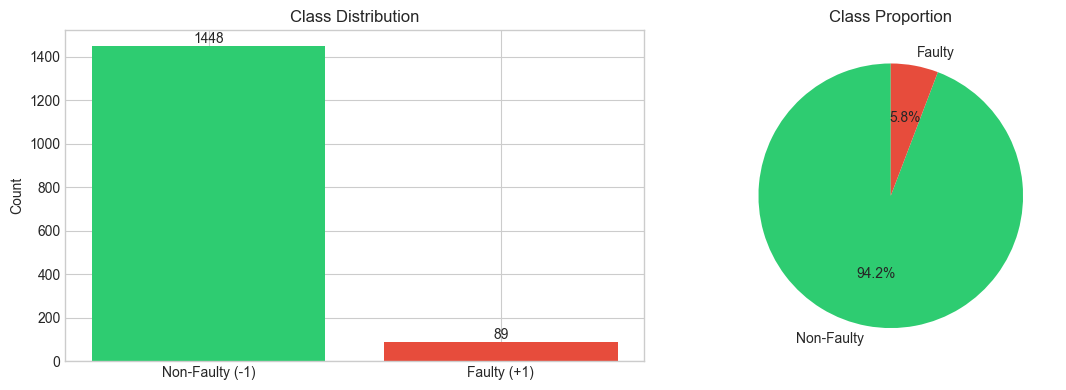

In [14]:
# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
ax = axes[0]
counts = data['Good/Bad'].value_counts()
bars = ax.bar(['Non-Faulty (-1)', 'Faulty (+1)'], [counts[-1], counts[1]],
              color=['#2ecc71', '#e74c3c'])
ax.set_title("Class Distribution")
ax.set_ylabel("Count")
for bar in bars:
    ax.annotate(f'{int(bar.get_height())}',
                (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                ha='center', va='bottom')

# Pie chart
ax = axes[1]
ax.pie([counts[-1], counts[1]], labels=['Non-Faulty', 'Faulty'],
       colors=['#2ecc71', '#e74c3c'], autopct='%1.1f%%', startangle=90)
ax.set_title("Class Proportion")

plt.tight_layout()
plt.show()

**Insight:** The dataset is highly imbalanced with the majority of wafers being non-faulty. This imbalance needs to be considered during model training and evaluation. Metrics like ROC AUC and F1-score will be more informative than accuracy alone.

### 4.3 Removing Identifier Column

In [17]:
# The 'Unnamed: 0' column contains Wafer IDs - not useful for prediction
wafer_ids = data['Unnamed: 0'].copy()
data.drop('Unnamed: 0', axis=1, inplace=True)
print("Dropped Wafer ID column.")
print("Remaining columns:", data.shape[1])

Dropped Wafer ID column.
Remaining columns: 591


### 4.4 Separating Features and Target

In [19]:
# Separate features (X) and target (Y)
X = data.drop('Good/Bad', axis=1)
Y = data['Good/Bad']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", Y.shape)
print("Number of sensor features:", X.shape[1])

Feature matrix shape: (1537, 590)
Target vector shape: (1537,)
Number of sensor features: 590


## 5. Missing Values Analysis

In [21]:
# Overall missing value statistics
total_missing = X.isnull().sum().sum()
total_cells = X.shape[0] * X.shape[1]
print(f"Total missing values: {total_missing}")
print(f"Total data cells: {total_cells}")
print(f"Percentage missing: {total_missing/total_cells*100:.2f}%")
print()

# Columns with missing values
null_cols = X.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=False)
print(f"Number of columns with missing values: {len(null_cols)} out of {X.shape[1]}")

Total missing values: 41131
Total data cells: 906830
Percentage missing: 4.54%

Number of columns with missing values: 534 out of 590


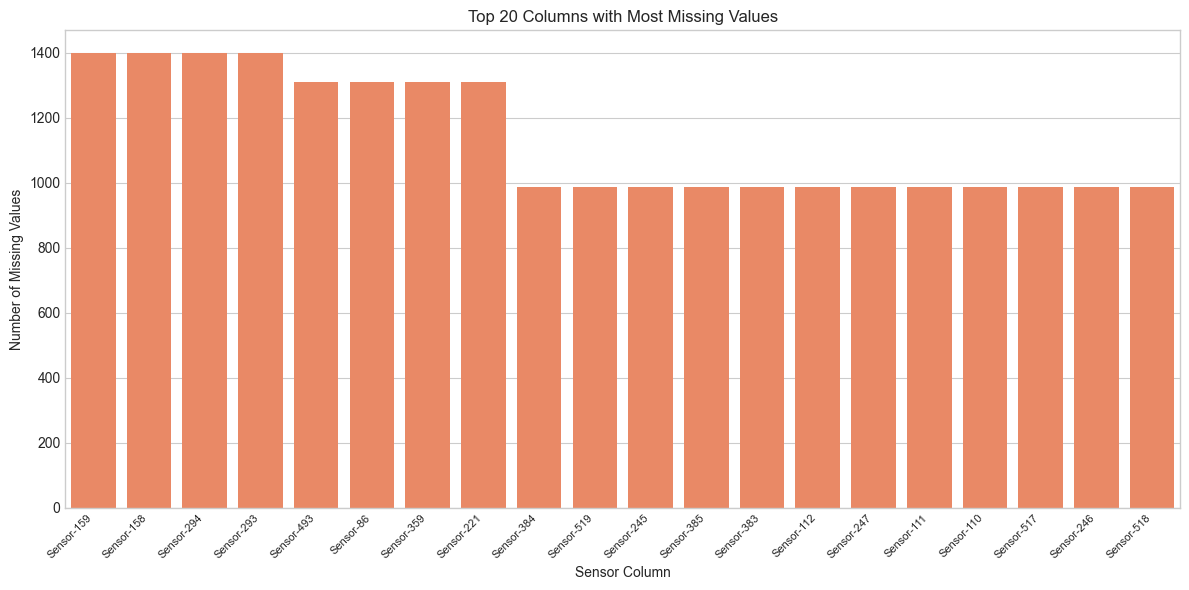

In [22]:
# Top 20 columns with most missing values
top_missing = null_cols.head(20)
plt.figure(figsize=(12, 6))
sns.barplot(x=top_missing.index, y=top_missing.values, color='coral')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title("Top 20 Columns with Most Missing Values")
plt.ylabel("Number of Missing Values")
plt.xlabel("Sensor Column")
plt.tight_layout()
plt.show()

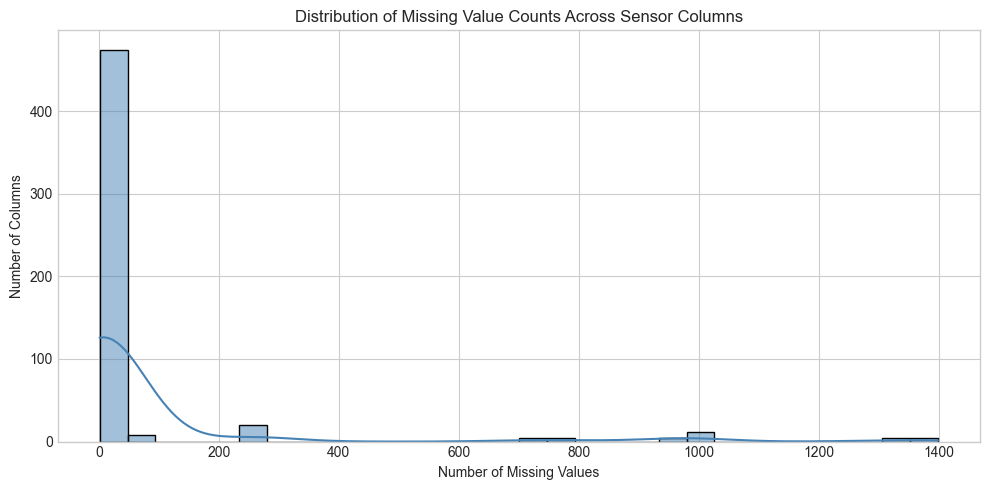

Median missing count per column: 6
Max missing count per column: 1399


In [23]:
# Distribution of missing value counts across columns
plt.figure(figsize=(10, 5))
missing_per_col = X.isnull().sum()
missing_per_col_nonzero = missing_per_col[missing_per_col > 0]
sns.histplot(missing_per_col_nonzero, bins=30, kde=True, color='steelblue')
plt.title("Distribution of Missing Value Counts Across Sensor Columns")
plt.xlabel("Number of Missing Values")
plt.ylabel("Number of Columns")
plt.tight_layout()
plt.show()

print(f"Median missing count per column: {missing_per_col_nonzero.median():.0f}")
print(f"Max missing count per column: {missing_per_col_nonzero.max()}")

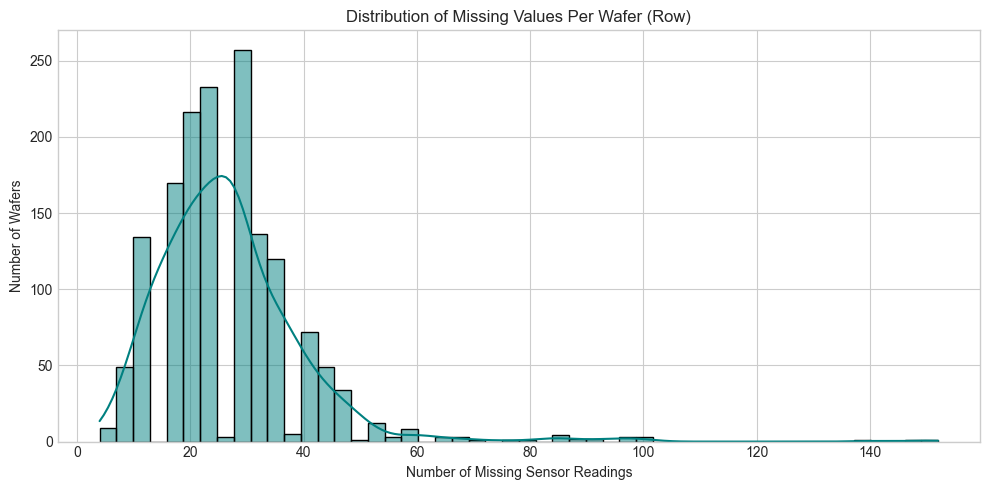

Wafers with zero missing values: 0
Wafers with >100 missing values: 3


In [24]:
# Missing values per row
missing_per_row = X.isnull().sum(axis=1)
plt.figure(figsize=(10, 5))
sns.histplot(missing_per_row, bins=50, kde=True, color='teal')
plt.title("Distribution of Missing Values Per Wafer (Row)")
plt.xlabel("Number of Missing Sensor Readings")
plt.ylabel("Number of Wafers")
plt.tight_layout()
plt.show()

print(f"Wafers with zero missing values: {(missing_per_row == 0).sum()}")
print(f"Wafers with >100 missing values: {(missing_per_row > 100).sum()}")

**Insight:** A significant number of sensor columns have missing readings. Rather than dropping these columns (which would lose potentially useful information), we use KNN Imputation as implemented in the original project. This approach fills missing values based on the k-nearest neighbors in the feature space.

## 6. Missing Value Imputation (KNN Imputer)

In [27]:
# Apply KNN Imputer with 3 neighbors (as per original project)
print("Applying KNN Imputer (n_neighbors=3)...")
print("This may take a few minutes due to the high dimensionality...")

imputer = KNNImputer(n_neighbors=3, weights='uniform', missing_values=np.nan)
X_imputed = imputer.fit_transform(X)
X = pd.DataFrame(data=X_imputed, columns=X.columns)

print("Imputation complete.")
print("Remaining missing values:", X.isnull().sum().sum())

Applying KNN Imputer (n_neighbors=3)...
This may take a few minutes due to the high dimensionality...
Imputation complete.
Remaining missing values: 0


## 7. Removing Zero-Variance Features

In [29]:
# Identify columns with zero standard deviation (constant values)
col_std = X.describe().loc['std']
zero_std_cols = col_std[col_std == 0].index.tolist()

print(f"Number of columns with zero standard deviation: {len(zero_std_cols)}")
print(f"These columns provide no discriminatory information and will be removed.")
if len(zero_std_cols) > 0:
    print(f"Sample zero-variance columns: {zero_std_cols[:10]}")

Number of columns with zero standard deviation: 116
These columns provide no discriminatory information and will be removed.
Sample zero-variance columns: ['Sensor-6', 'Sensor-14', 'Sensor-43', 'Sensor-50', 'Sensor-53', 'Sensor-70', 'Sensor-98', 'Sensor-142', 'Sensor-150', 'Sensor-179']


In [30]:
# Remove zero-variance columns
X.drop(zero_std_cols, axis=1, inplace=True)
print(f"Shape after removing zero-variance columns: {X.shape}")
print(f"Remaining sensor features: {X.shape[1]}")

Shape after removing zero-variance columns: (1537, 474)
Remaining sensor features: 474


**Insight:** A large number of sensors (approximately 116) have constant readings across all wafers. These provide zero information for distinguishing between faulty and non-faulty wafers and are removed to reduce noise and computational cost.

## 8. Detailed Exploratory Data Analysis

### 8.1 Sensor Value Distribution Overview

In [34]:
# Distribution statistics after cleaning
print("Feature Statistics After Preprocessing:")
print(f"  Number of features: {X.shape[1]}")
print(f"  Number of samples: {X.shape[0]}")
print()

# Basic stats
desc = X.describe()
print("Range of feature means: [{:.2f}, {:.2f}]".format(desc.loc['mean'].min(), desc.loc['mean'].max()))
print("Range of feature stds:  [{:.2f}, {:.2f}]".format(desc.loc['std'].min(), desc.loc['std'].max()))

Feature Statistics After Preprocessing:
  Number of features: 474
  Number of samples: 1537

Range of feature means: [-5632.43, 8825.51]
Range of feature stds:  [0.00, 6596.63]


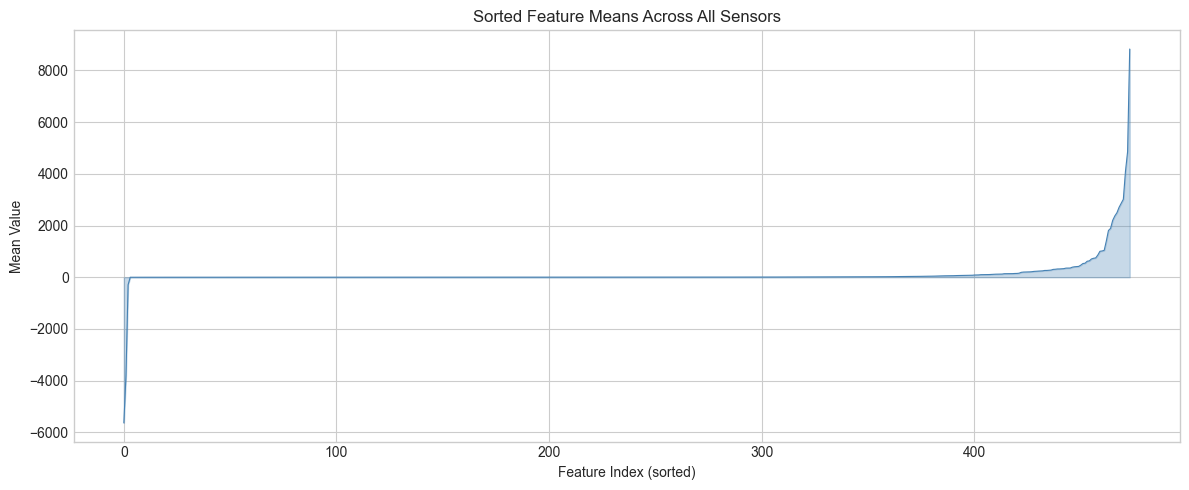

In [35]:
# Distribution of feature means
plt.figure(figsize=(12, 5))
feature_means = X.mean().sort_values()
plt.plot(range(len(feature_means)), feature_means.values, color='steelblue', linewidth=0.8)
plt.fill_between(range(len(feature_means)), feature_means.values, alpha=0.3, color='steelblue')
plt.title("Sorted Feature Means Across All Sensors")
plt.xlabel("Feature Index (sorted)")
plt.ylabel("Mean Value")
plt.tight_layout()
plt.show()

### 8.2 Comparing Faulty vs Non-Faulty Sensor Readings

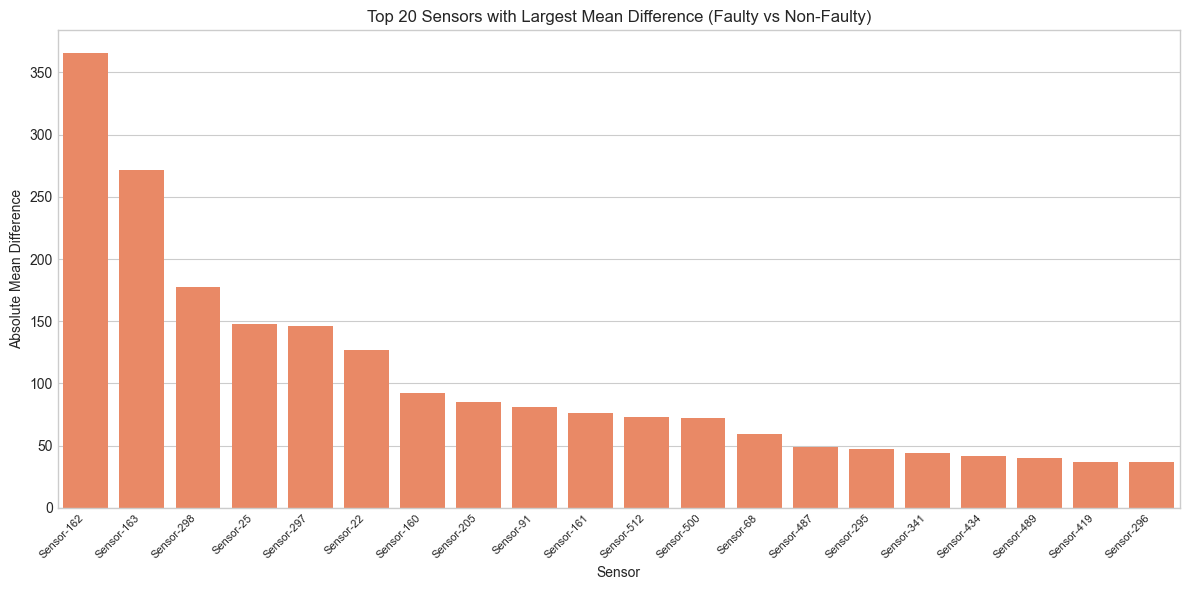

Top 5 most discriminative sensors:
  Sensor-162: mean diff = 365.5595
  Sensor-163: mean diff = 271.4426
  Sensor-298: mean diff = 177.6004
  Sensor-25: mean diff = 147.5763
  Sensor-297: mean diff = 146.2609


In [37]:
# Compare mean sensor readings for faulty vs non-faulty wafers
X_temp = X.copy()
X_temp['Target'] = Y.values

good_means = X_temp[X_temp['Target'] == -1].drop('Target', axis=1).mean()
bad_means = X_temp[X_temp['Target'] == 1].drop('Target', axis=1).mean()

# Find sensors with largest mean difference
diff = (bad_means - good_means).abs().sort_values(ascending=False)
top_diff_sensors = diff.head(20)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_diff_sensors.index, y=top_diff_sensors.values, color='coral')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.title("Top 20 Sensors with Largest Mean Difference (Faulty vs Non-Faulty)")
plt.ylabel("Absolute Mean Difference")
plt.xlabel("Sensor")
plt.tight_layout()
plt.show()

print("Top 5 most discriminative sensors:")
for s, v in diff.head(5).items():
    print(f"  {s}: mean diff = {v:.4f}")

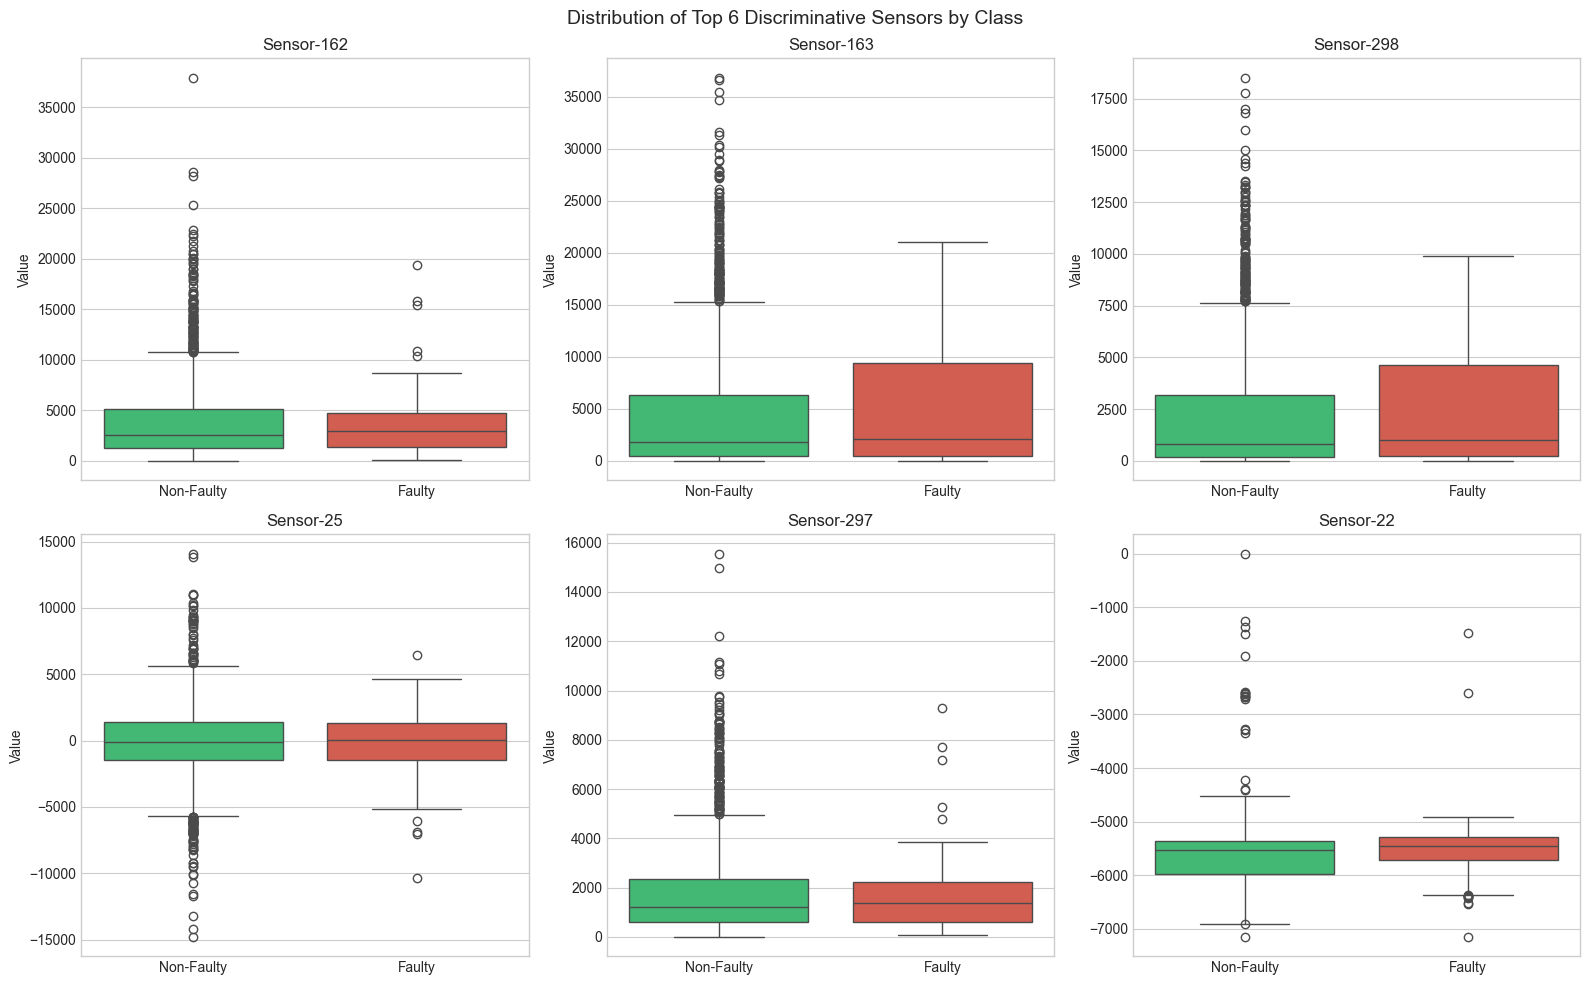

In [38]:
# Box plots for top 6 most discriminative sensors
top6 = diff.head(6).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, sensor in enumerate(top6):
    plot_data = pd.DataFrame({
        'Value': X[sensor],
        'Class': Y.map({-1: 'Non-Faulty', 1: 'Faulty'})
    })
    sns.boxplot(x='Class', y='Value', data=plot_data, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'])
    axes[i].set_title(sensor)
    axes[i].set_xlabel("")

plt.suptitle("Distribution of Top 6 Discriminative Sensors by Class", fontsize=14)
plt.tight_layout()
plt.show()

### 8.3 Correlation Analysis

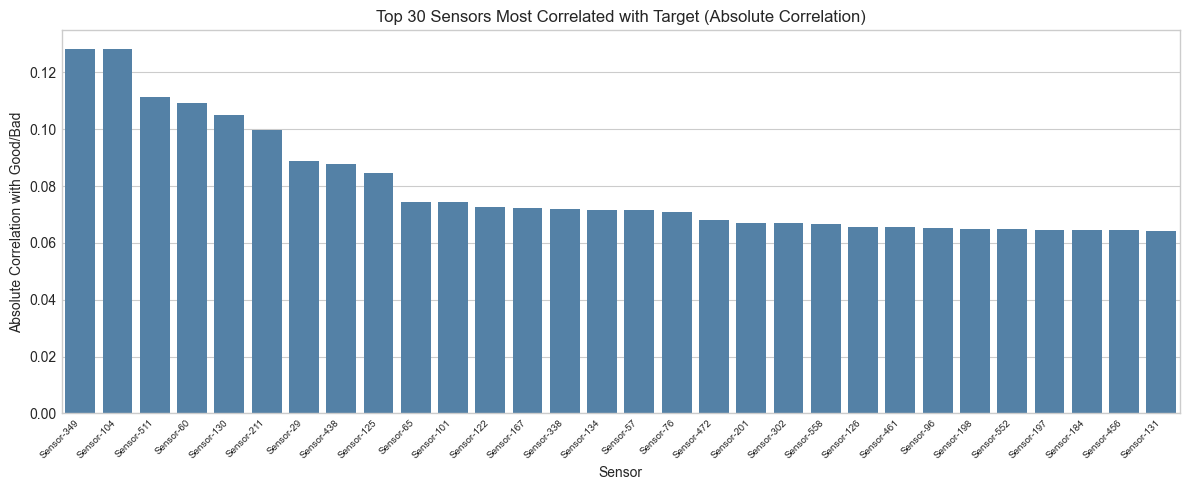

Top 10 correlated sensors:
  Sensor-349: |corr| = 0.1283
  Sensor-104: |corr| = 0.1283
  Sensor-511: |corr| = 0.1113
  Sensor-60: |corr| = 0.1094
  Sensor-130: |corr| = 0.1050
  Sensor-211: |corr| = 0.0998
  Sensor-29: |corr| = 0.0887
  Sensor-438: |corr| = 0.0879
  Sensor-125: |corr| = 0.0846
  Sensor-65: |corr| = 0.0743


In [40]:
# Correlation of features with the target variable
target_corr = X.corrwith(Y).abs().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
top_corr = target_corr.head(30)
sns.barplot(x=top_corr.index, y=top_corr.values, color='steelblue')
plt.xticks(rotation=45, ha='right', fontsize=7)
plt.title("Top 30 Sensors Most Correlated with Target (Absolute Correlation)")
plt.ylabel("Absolute Correlation with Good/Bad")
plt.xlabel("Sensor")
plt.tight_layout()
plt.show()

print("Top 10 correlated sensors:")
for s, v in target_corr.head(10).items():
    print(f"  {s}: |corr| = {v:.4f}")

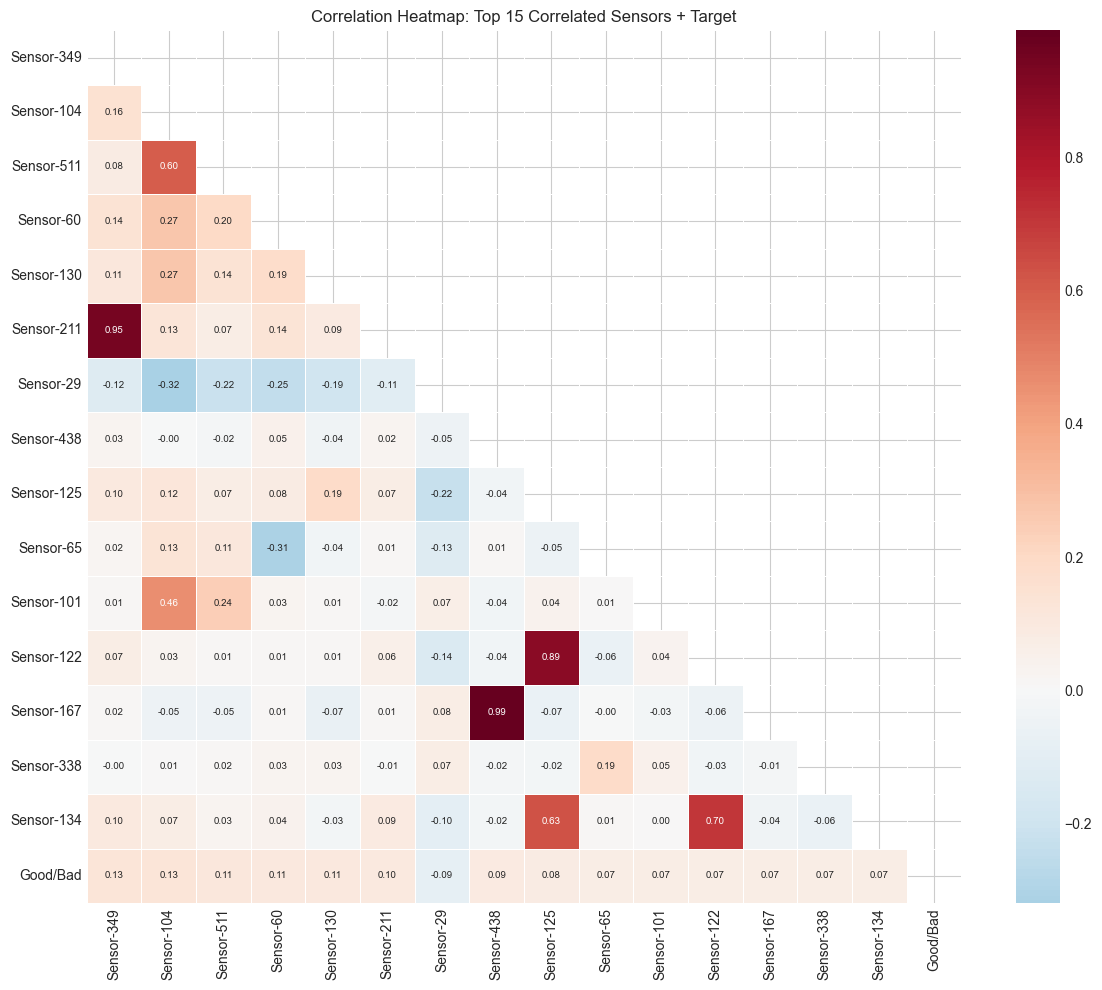

In [41]:
# Correlation heatmap for top 15 correlated sensors + target
top15_sensors = target_corr.head(15).index.tolist()
corr_subset = X[top15_sensors].copy()
corr_subset['Good/Bad'] = Y.values
corr_matrix = corr_subset.corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title("Correlation Heatmap: Top 15 Correlated Sensors + Target")
plt.tight_layout()
plt.show()

### 8.4 PCA Visualization

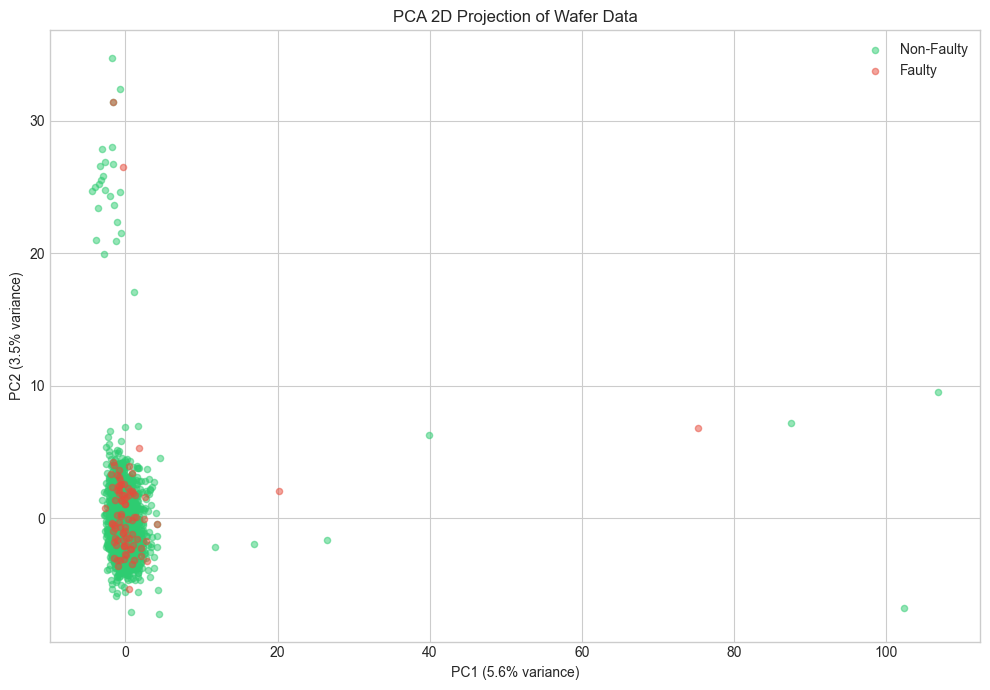

Variance explained by PC1: 5.61%
Variance explained by PC2: 3.53%
Total variance explained: 9.14%


In [43]:
# PCA for 2D visualization of the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_2d = PCA(n_components=2, random_state=42)
X_pca = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
colors = {-1: '#2ecc71', 1: '#e74c3c'}
labels = {-1: 'Non-Faulty', 1: 'Faulty'}
for cls in [-1, 1]:
    mask = Y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=colors[cls], label=labels[cls],
                alpha=0.5, s=20)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.title("PCA 2D Projection of Wafer Data")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Variance explained by PC1: {pca_2d.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca_2d.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

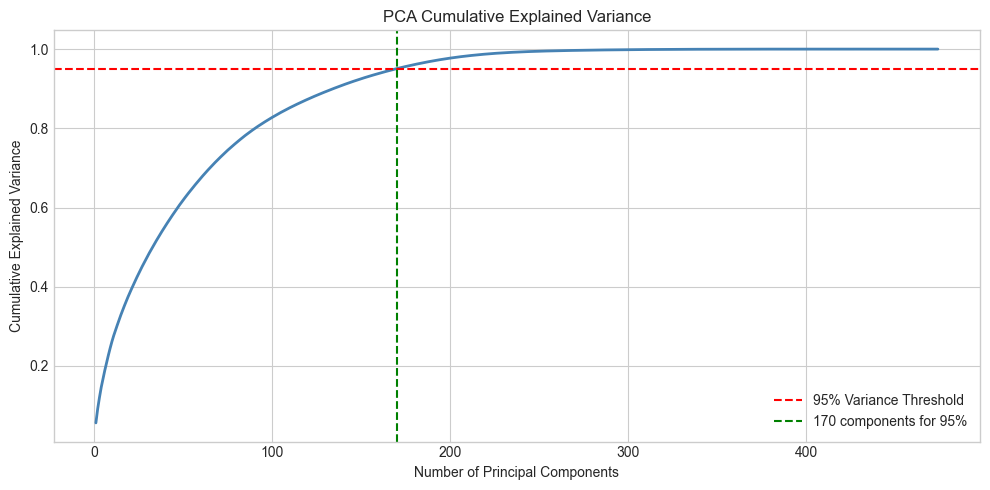

Components needed for 95% variance: 170
Components needed for 99% variance: 228


In [44]:
# Cumulative explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)
cum_var = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, len(cum_var)+1), cum_var, color='steelblue', linewidth=2)
plt.axhline(y=0.95, color='red', linestyle='--', label='95% Variance Threshold')
n_95 = np.argmax(cum_var >= 0.95) + 1
plt.axvline(x=n_95, color='green', linestyle='--', label=f'{n_95} components for 95%')
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Cumulative Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Components needed for 95% variance: {n_95}")
print(f"Components needed for 99% variance: {np.argmax(cum_var >= 0.99) + 1}")

### 8.5 Feature Variance Analysis

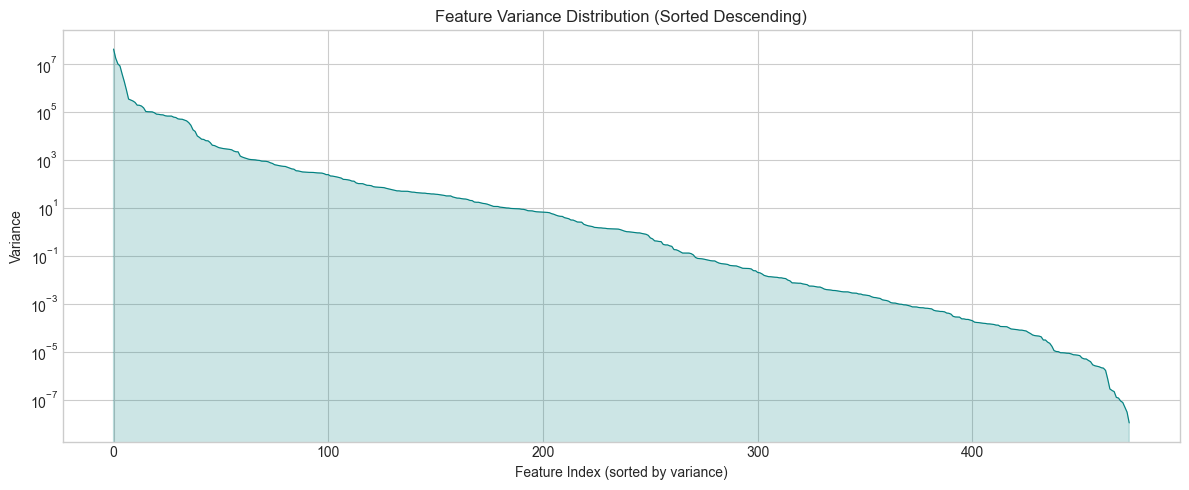

Features with variance > 1000: 67
Features with variance < 1: 232
Features with variance < 0.01: 160


In [46]:
# Distribution of feature variances
feature_var = X.var().sort_values(ascending=False)

plt.figure(figsize=(12, 5))
plt.plot(range(len(feature_var)), feature_var.values, color='teal', linewidth=0.8)
plt.fill_between(range(len(feature_var)), feature_var.values, alpha=0.2, color='teal')
plt.title("Feature Variance Distribution (Sorted Descending)")
plt.xlabel("Feature Index (sorted by variance)")
plt.ylabel("Variance")
plt.yscale('log')
plt.tight_layout()
plt.show()

print(f"Features with variance > 1000: {(feature_var > 1000).sum()}")
print(f"Features with variance < 1: {(feature_var < 1).sum()}")
print(f"Features with variance < 0.01: {(feature_var < 0.01).sum()}")

## 9. KMeans Clustering

As implemented in the original project, KMeans clustering is applied to segment the data before training separate models for each cluster. This approach allows different models to specialize on different data subgroups.

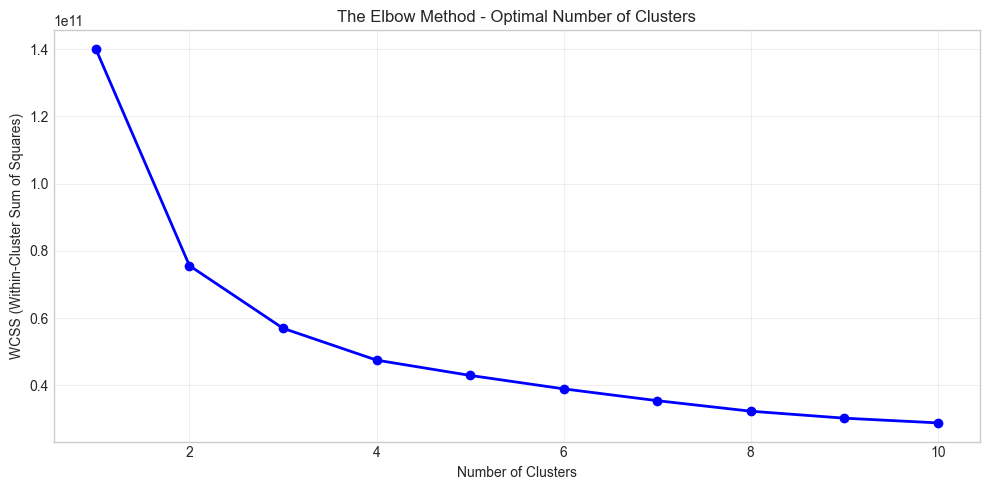

In [49]:
# Elbow method to find optimal number of clusters
wcss = []
K_range = range(1, 11)

for i in K_range:
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, 'bo-', linewidth=2)
plt.title("The Elbow Method - Optimal Number of Clusters")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS (Within-Cluster Sum of Squares)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# Programmatically find the optimal number of clusters using the Kneed library
from kneed import KneeLocator

kn = KneeLocator(list(K_range), wcss, curve='convex', direction='decreasing')
optimal_k = kn.knee
print(f"Optimal number of clusters (elbow point): {optimal_k}")

Optimal number of clusters (elbow point): 3


In [51]:
# Apply KMeans with optimal clusters
kmeans = KMeans(n_clusters=optimal_k, init='k-means++', random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)
X['Cluster'] = cluster_labels

print("Cluster distribution:")
print(pd.Series(cluster_labels).value_counts().sort_index())

Cluster distribution:
0    1042
1     307
2     188
Name: count, dtype: int64


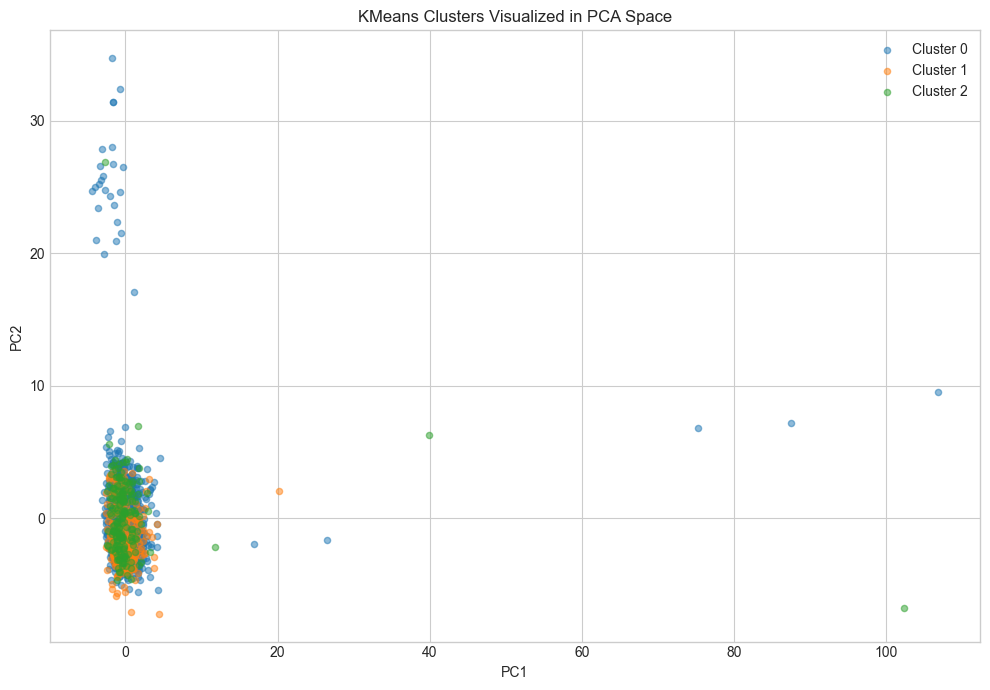

In [52]:
# Visualize clusters using PCA
plt.figure(figsize=(10, 7))
for c in range(optimal_k):
    mask = cluster_labels == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=f'Cluster {c}', alpha=0.5, s=20)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters Visualized in PCA Space")
plt.legend()
plt.tight_layout()
plt.show()

In [53]:
# Class distribution within each cluster
print("Class distribution per cluster:")
print("=" * 50)
for c in range(optimal_k):
    mask = X['Cluster'] == c
    cluster_target = Y[mask]
    good_count = (cluster_target == -1).sum()
    bad_count = (cluster_target == 1).sum()
    total = len(cluster_target)
    print(f"Cluster {c}: Total={total}, Non-Faulty={good_count} ({good_count/total*100:.1f}%), "
          f"Faulty={bad_count} ({bad_count/total*100:.1f}%)")

Class distribution per cluster:
Cluster 0: Total=1042, Non-Faulty=982 (94.2%), Faulty=60 (5.8%)
Cluster 1: Total=307, Non-Faulty=286 (93.2%), Faulty=21 (6.8%)
Cluster 2: Total=188, Non-Faulty=180 (95.7%), Faulty=8 (4.3%)


## 10. Per-Cluster Model Training

Following the original project architecture, we train separate models for each cluster. For each cluster, both Random Forest and XGBoost are tuned using GridSearchCV, and the better model is selected based on ROC AUC score.

In [56]:
# Add target labels for cluster-based training
X['Labels'] = Y.values
cluster_list = X['Cluster'].unique()

# Store results for all clusters
all_cluster_results = {}
best_models = {}

print("Training models for each cluster...")
print("=" * 70)

for cluster_id in sorted(cluster_list):
    print(f"\n--- Cluster {cluster_id} ---")
    
    # Filter data for this cluster
    cluster_data = X[X['Cluster'] == cluster_id]
    cluster_features = cluster_data.drop(['Labels', 'Cluster'], axis=1)
    cluster_label = cluster_data['Labels']
    
    print(f"  Samples: {len(cluster_data)}, Features: {cluster_features.shape[1]}")
    print(f"  Class distribution: {dict(cluster_label.value_counts())}")
    
    # Split into train and test
    x_train, x_test, y_train, y_test = train_test_split(
        cluster_features, cluster_label, test_size=0.33, random_state=355)
    
    # --- Random Forest with GridSearchCV ---
    rf_params = {
        "n_estimators": [10, 50, 100],
        "criterion": ['gini', 'entropy'],
        "max_depth": [2, 3]
    }
    rf_grid = GridSearchCV(
        RandomForestClassifier(random_state=42),
        rf_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
    rf_grid.fit(x_train, y_train)
    rf_best = rf_grid.best_estimator_
    rf_pred = rf_best.predict(x_test)
    
    if len(y_test.unique()) == 1:
        rf_score = accuracy_score(y_test, rf_pred)
        metric_name = "Accuracy"
    else:
        rf_score = roc_auc_score(y_test, rf_pred)
        metric_name = "ROC AUC"
    
    print(f"  Random Forest - Best params: {rf_grid.best_params_}")
    print(f"  Random Forest - {metric_name}: {rf_score:.4f}")
    
    # --- XGBoost with GridSearchCV ---
    xgb_params = {
        'learning_rate': [0.1, 0.01],
        'max_depth': [3, 5],
        'n_estimators': [50, 100]
    }
    xgb_grid = GridSearchCV(
        XGBClassifier(objective='binary:logistic', eval_metric='logloss',
                      random_state=42, use_label_encoder=False),
        xgb_params, cv=3, scoring='roc_auc', n_jobs=-1, verbose=0)
    
    # XGBoost needs 0/1 labels
    y_train_xgb = y_train.map({-1: 0, 1: 1})
    y_test_xgb = y_test.map({-1: 0, 1: 1})
    xgb_grid.fit(x_train, y_train_xgb)
    xgb_best = xgb_grid.best_estimator_
    xgb_pred = xgb_best.predict(x_test)
    
    # Map predictions back for comparison
    xgb_pred_orig = pd.Series(xgb_pred).map({0: -1, 1: 1}).values
    
    if len(y_test.unique()) == 1:
        xgb_score = accuracy_score(y_test_xgb, xgb_pred)
    else:
        xgb_score = roc_auc_score(y_test_xgb, xgb_pred)
    
    print(f"  XGBoost - Best params: {xgb_grid.best_params_}")
    print(f"  XGBoost - {metric_name}: {xgb_score:.4f}")
    
    # Select the better model
    if rf_score >= xgb_score:
        best_name = 'RandomForest'
        best_model = rf_best
        best_score = rf_score
        best_pred = rf_pred
    else:
        best_name = 'XGBoost'
        best_model = xgb_best
        best_score = xgb_score
        best_pred = xgb_pred_orig
    
    print(f"  >>> Best model: {best_name} ({metric_name}: {best_score:.4f})")
    
    best_models[cluster_id] = {'name': best_name, 'model': best_model, 'score': best_score}
    all_cluster_results[cluster_id] = {
        'best_model': best_name,
        'rf_score': rf_score,
        'xgb_score': xgb_score,
        'best_score': best_score,
        'rf_params': rf_grid.best_params_,
        'xgb_params': xgb_grid.best_params_,
        'samples': len(cluster_data)
    }

Training models for each cluster...

--- Cluster 0 ---
  Samples: 1042, Features: 474
  Class distribution: {-1: 982, 1: 60}
  Random Forest - Best params: {'criterion': 'entropy', 'max_depth': 2, 'n_estimators': 100}
  Random Forest - ROC AUC: 0.5000
  XGBoost - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
  XGBoost - ROC AUC: 0.5000
  >>> Best model: RandomForest (ROC AUC: 0.5000)

--- Cluster 1 ---
  Samples: 307, Features: 474
  Class distribution: {-1: 286, 1: 21}
  Random Forest - Best params: {'criterion': 'gini', 'max_depth': 2, 'n_estimators': 100}
  Random Forest - ROC AUC: 0.5000
  XGBoost - Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}
  XGBoost - ROC AUC: 0.5000
  >>> Best model: RandomForest (ROC AUC: 0.5000)

--- Cluster 2 ---
  Samples: 188, Features: 474
  Class distribution: {-1: 180, 1: 8}
  Random Forest - Best params: {'criterion': 'gini', 'max_depth': 2, 'n_estimators': 100}
  Random Forest - ROC AUC: 0.5000
  

### 10.1 Cluster-Level Results Summary

In [58]:
# Summary table
results_df = pd.DataFrame(all_cluster_results).T
results_df.index.name = 'Cluster'
print("Cluster-Level Model Selection Summary:")
results_df[['best_model', 'rf_score', 'xgb_score', 'best_score', 'samples']]

Cluster-Level Model Selection Summary:


,best_model,rf_score,xgb_score,best_score,samples
Cluster,,,,,
0,RandomForest,0.5,0.5,0.5,1042
1,RandomForest,0.5,0.5,0.5,307
2,RandomForest,0.5,0.5,0.5,188


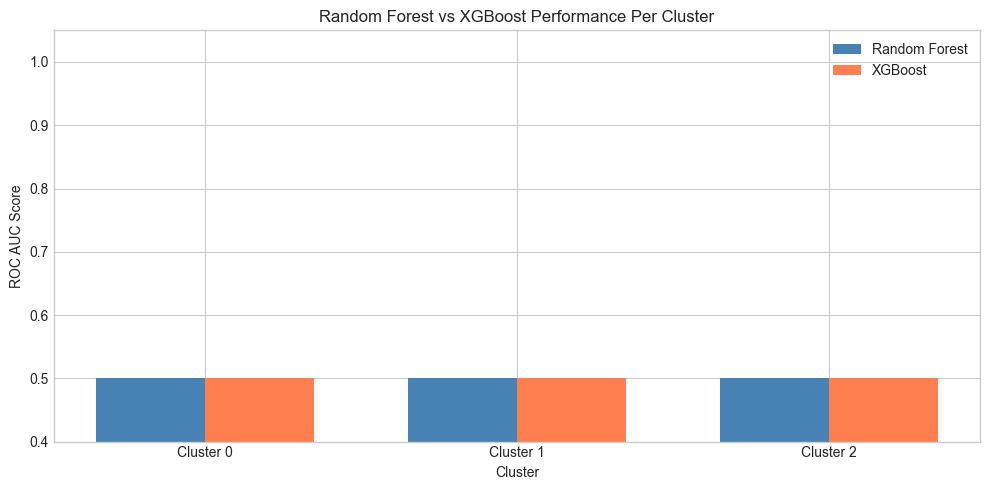

In [59]:
# Visualize per-cluster performance
fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.35
clusters = sorted(all_cluster_results.keys())
x = np.arange(len(clusters))

rf_scores = [all_cluster_results[c]['rf_score'] for c in clusters]
xgb_scores = [all_cluster_results[c]['xgb_score'] for c in clusters]

bars1 = ax.bar(x - bar_width/2, rf_scores, bar_width, label='Random Forest', color='steelblue')
bars2 = ax.bar(x + bar_width/2, xgb_scores, bar_width, label='XGBoost', color='coral')

ax.set_xlabel('Cluster')
ax.set_ylabel('ROC AUC Score')
ax.set_title('Random Forest vs XGBoost Performance Per Cluster')
ax.set_xticks(x)
ax.set_xticklabels([f'Cluster {c}' for c in clusters])
ax.legend()
ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

## 11. Consolidated Model Training (Full Dataset)

In addition to the per-cluster approach, we also train models on the full dataset for comparison and simplicity.

In [62]:
# Prepare full dataset (without cluster column)
X_full = X.drop(['Cluster', 'Labels'], axis=1)
Y_full = Y.copy()

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_full, Y_full, test_size=0.2, random_state=42, stratify=Y_full)

print("Full dataset split:")
print(f"  Training set: {X_train.shape}")
print(f"  Test set: {X_test.shape}")

Full dataset split:
  Training set: (1229, 474)
  Test set: (308, 474)


In [63]:
# Train multiple models on the full dataset
y_train_binary = y_train.map({-1: 0, 1: 1})
y_test_binary = y_test.map({-1: 0, 1: 1})

full_models = {}

# 1. Random Forest
print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=3, criterion='entropy',
                            random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
full_models['Random Forest'] = {'model': rf, 'pred': rf_pred, 'prob': rf_prob}

# 2. XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100,
                     objective='binary:logistic', eval_metric='logloss',
                     random_state=42, use_label_encoder=False)
xgb.fit(X_train, y_train_binary)
xgb_pred_binary = xgb.predict(X_test)
xgb_prob = xgb.predict_proba(X_test)[:, 1]
xgb_pred = pd.Series(xgb_pred_binary).map({0: -1, 1: 1}).values
full_models['XGBoost'] = {'model': xgb, 'pred': xgb_pred, 'prob': xgb_prob}

# 3. Logistic Regression
print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
full_models['Logistic Regression'] = {'model': lr, 'pred': lr_pred, 'prob': lr_prob}

print("All models trained successfully.")

Training Random Forest...
Training XGBoost...
Training Logistic Regression...
All models trained successfully.


### 11.1 Full Dataset Model Comparison

In [65]:
# Evaluate all models
print("Full Dataset Model Evaluation")
print("=" * 70)

eval_results = {}
for name, info in full_models.items():
    pred = info['pred']
    prob = info['prob']
    
    acc = accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, pos_label=1)
    prec = precision_score(y_test, pred, pos_label=1, zero_division=0)
    rec = recall_score(y_test, pred, pos_label=1)
    
    # ROC AUC needs binary labels for prob
    y_test_bin = y_test.map({-1: 0, 1: 1})
    auc = roc_auc_score(y_test_bin, prob)
    mcc = matthews_corrcoef(y_test, pred)
    
    eval_results[name] = {
        'Accuracy': acc, 'F1 Score': f1, 'Precision': prec,
        'Recall': rec, 'ROC AUC': auc, 'MCC': mcc
    }
    
    print(f"{name}:")
    print(f"  Accuracy:    {acc:.4f}")
    print(f"  F1 Score:    {f1:.4f}")
    print(f"  Precision:   {prec:.4f}")
    print(f"  Recall:      {rec:.4f}")
    print(f"  ROC AUC:     {auc:.4f}")
    print(f"  MCC:         {mcc:.4f}")
    print("-" * 40)

eval_df = pd.DataFrame(eval_results).T.sort_values('ROC AUC', ascending=False)
eval_df

Full Dataset Model Evaluation
Random Forest:
  Accuracy:    0.9416
  F1 Score:    0.0000
  Precision:   0.0000
  Recall:      0.0000
  ROC AUC:     0.7163
  MCC:         0.0000
----------------------------------------
XGBoost:
  Accuracy:    0.9416
  F1 Score:    0.0000
  Precision:   0.0000
  Recall:      0.0000
  ROC AUC:     0.6370
  MCC:         0.0000
----------------------------------------
Logistic Regression:
  Accuracy:    0.9416
  F1 Score:    0.1000
  Precision:   0.5000
  Recall:      0.0556
  ROC AUC:     0.5151
  MCC:         0.1522
----------------------------------------


,Accuracy,F1 Score,Precision,Recall,ROC AUC,MCC
Random Forest,0.941558,0.0,0.0,0.000000,0.716284,0.00000
XGBoost,0.941558,0.0,0.0,0.000000,0.636973,0.00000
Logistic Regression,0.941558,0.1,0.5,0.055556,0.515134,0.15218


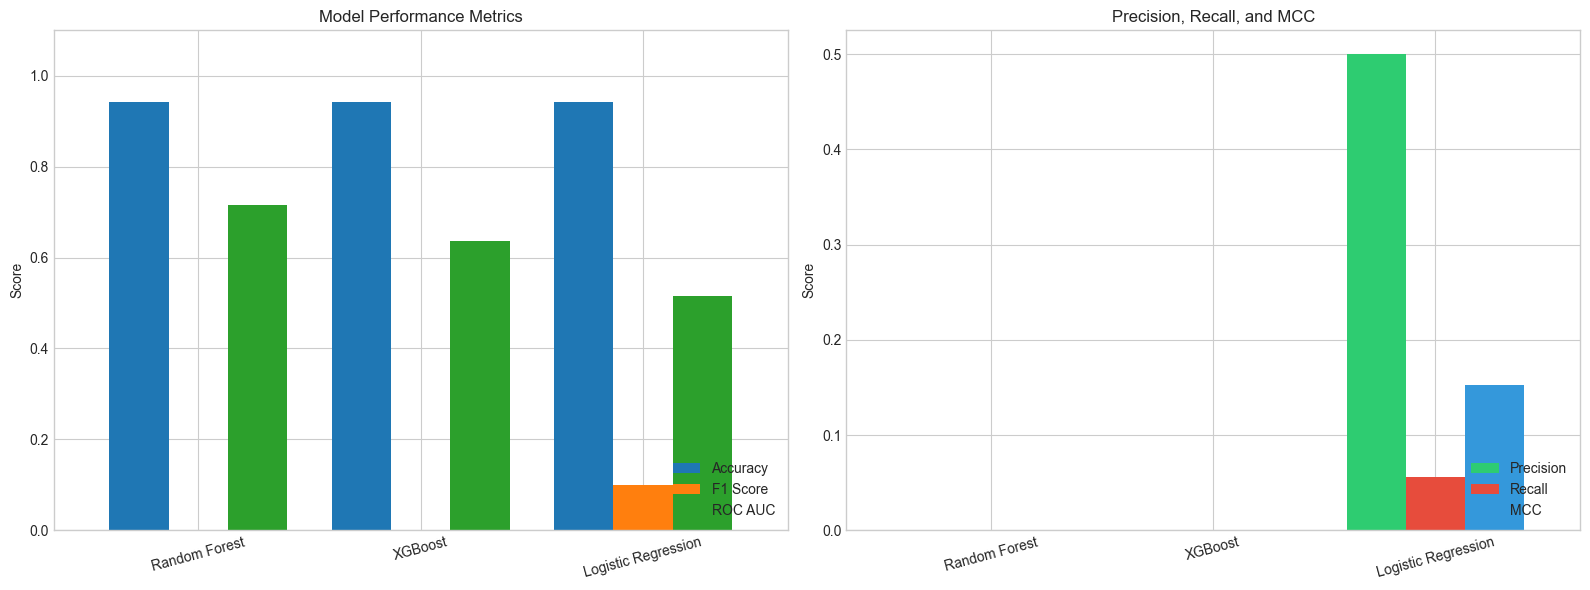

In [66]:
# Model comparison visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

eval_df[['Accuracy', 'F1 Score', 'ROC AUC']].plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title("Model Performance Metrics")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.1)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15)
axes[0].legend(loc='lower right')

eval_df[['Precision', 'Recall', 'MCC']].plot(kind='bar', ax=axes[1], width=0.8,
                                               color=['#2ecc71', '#e74c3c', '#3498db'])
axes[1].set_title("Precision, Recall, and MCC")
axes[1].set_ylabel("Score")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

### 11.2 ROC Curves

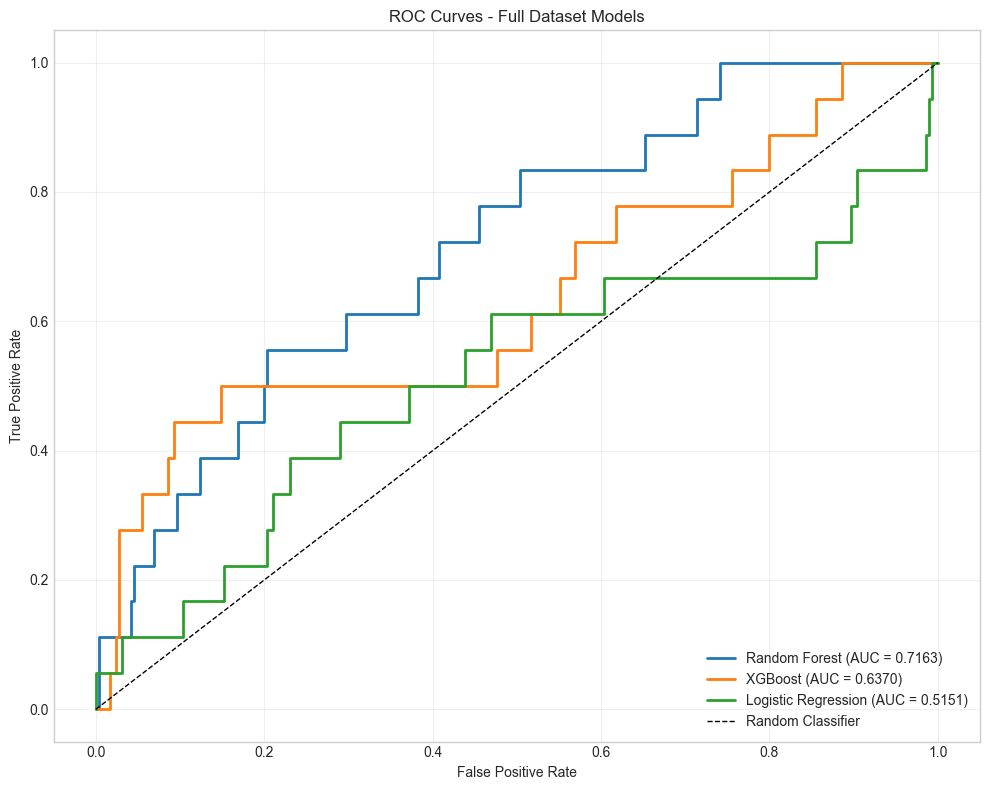

In [68]:
# ROC curves
plt.figure(figsize=(10, 8))
y_test_bin = y_test.map({-1: 0, 1: 1})

for name, info in full_models.items():
    fpr, tpr, _ = roc_curve(y_test_bin, info['prob'])
    auc = roc_auc_score(y_test_bin, info['prob'])
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Full Dataset Models')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.3 Confusion Matrices

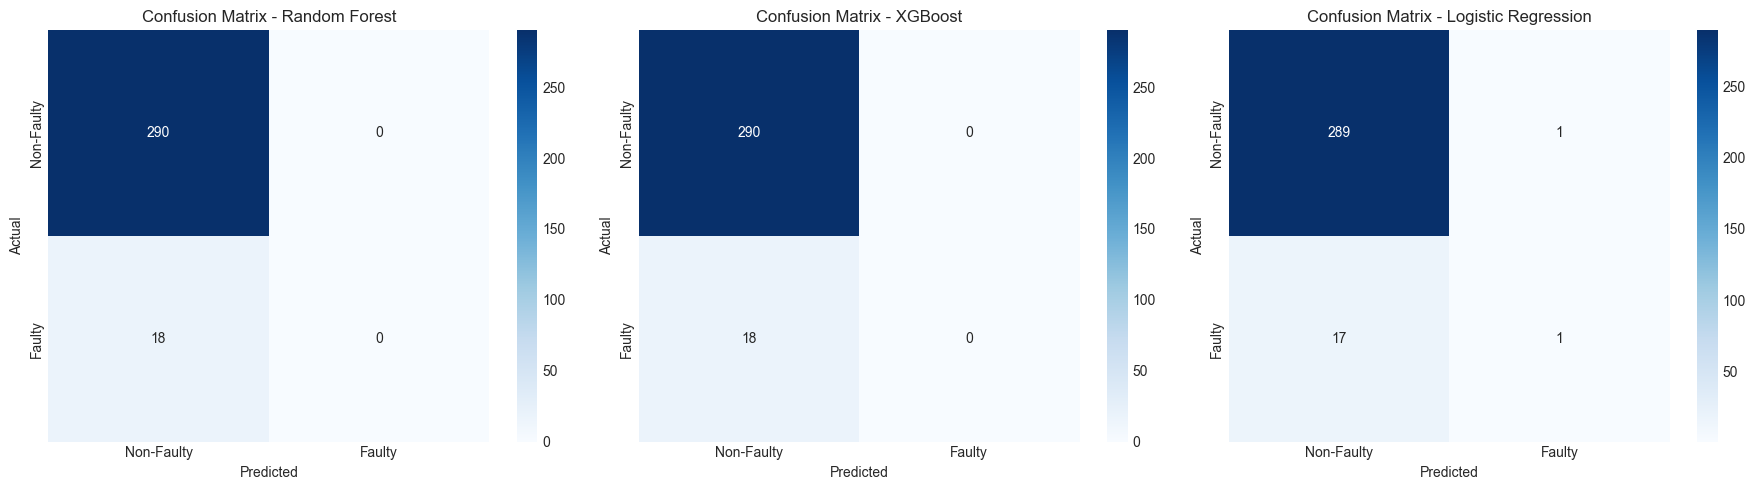

In [70]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (name, info) in enumerate(full_models.items()):
    cm = confusion_matrix(y_test, info['pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Non-Faulty', 'Faulty'],
                yticklabels=['Non-Faulty', 'Faulty'])
    axes[i].set_title(f"Confusion Matrix - {name}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

plt.tight_layout()
plt.show()

### 11.4 Best Model - Detailed Classification Report

In [72]:
# Best model classification report
best_full_model_name = eval_df.index[0]
best_info = full_models[best_full_model_name]

print(f"Best Full Dataset Model: {best_full_model_name}")
print("=" * 50)
print(classification_report(y_test, best_info['pred'],
                            target_names=['Non-Faulty (-1)', 'Faulty (+1)']))

Best Full Dataset Model: Random Forest
                 precision    recall  f1-score   support

Non-Faulty (-1)       0.94      1.00      0.97       290
    Faulty (+1)       0.00      0.00      0.00        18

       accuracy                           0.94       308
      macro avg       0.47      0.50      0.48       308
   weighted avg       0.89      0.94      0.91       308



### 11.5 Feature Importance

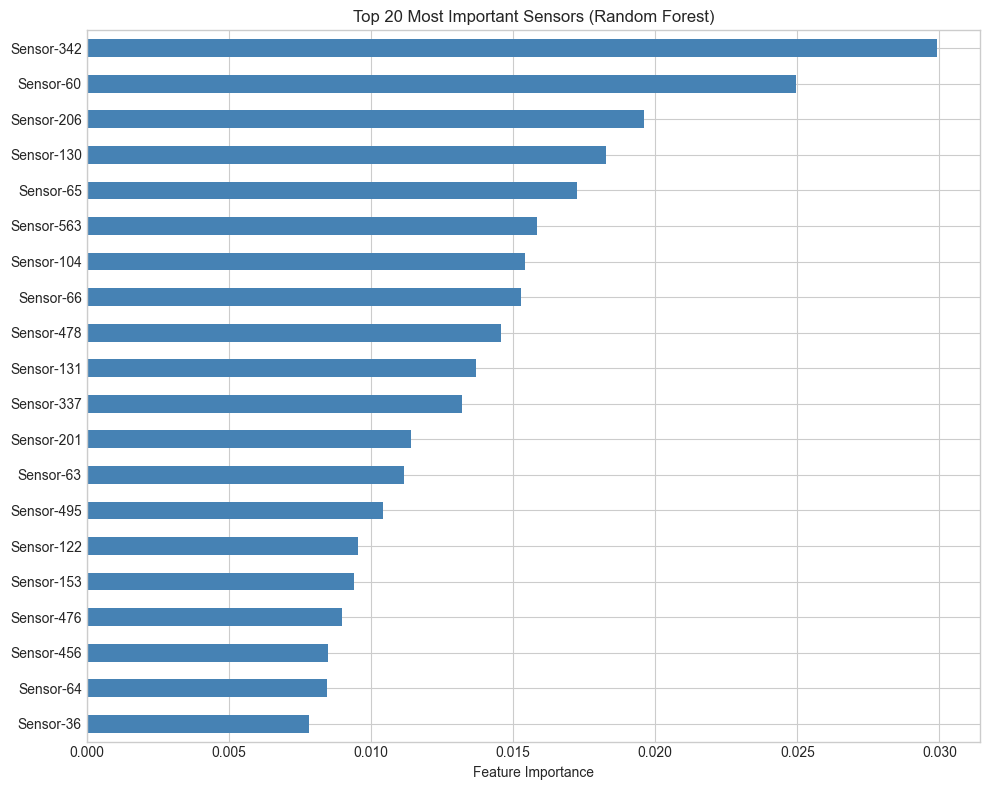

Top 10 most important sensors:
  Sensor-342: importance = 0.0299
  Sensor-60: importance = 0.0250
  Sensor-206: importance = 0.0196
  Sensor-130: importance = 0.0183
  Sensor-65: importance = 0.0172
  Sensor-563: importance = 0.0159
  Sensor-104: importance = 0.0154
  Sensor-66: importance = 0.0153
  Sensor-478: importance = 0.0146
  Sensor-131: importance = 0.0137


In [74]:
# Feature importance from Random Forest
rf_model = full_models['Random Forest']['model']
feat_imp = pd.Series(rf_model.feature_importances_,
                     index=X_full.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 8))
feat_imp.tail(20).plot(kind='barh', color='steelblue')
plt.title("Top 20 Most Important Sensors (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

print("Top 10 most important sensors:")
for s, v in feat_imp.tail(10).iloc[::-1].items():
    print(f"  {s}: importance = {v:.4f}")

### 11.6 Cross-Validation

In [76]:
# 5-fold cross-validation
print("5-Fold Cross-Validation Results")
print("=" * 50)

cv_models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=3,
                                            criterion='entropy', random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(learning_rate=0.1, max_depth=5, n_estimators=100,
                              objective='binary:logistic', eval_metric='logloss',
                              random_state=42, use_label_encoder=False)
}

# Map labels for XGBoost compatibility
Y_binary = Y_full.map({-1: 0, 1: 1})

cv_results = {}
for name, model in cv_models.items():
    if name == 'XGBoost':
        scores = cross_val_score(model, X_full, Y_binary, cv=5, scoring='roc_auc', n_jobs=-1)
    else:
        scores = cross_val_score(model, X_full, Y_full, cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}:")
    print(f"  Mean ROC AUC: {scores.mean():.4f} (+/- {scores.std():.4f})")
    print(f"  Fold scores: {[round(s, 4) for s in scores]}")
    print("-" * 40)

5-Fold Cross-Validation Results
Random Forest:
  Mean ROC AUC: 0.6778 (+/- 0.1292)
  Fold scores: [0.6628, 0.832, 0.7505, 0.4458, 0.698]
----------------------------------------
XGBoost:
  Mean ROC AUC: 0.6603 (+/- 0.1030)
  Fold scores: [0.6123, 0.7548, 0.7406, 0.48, 0.714]
----------------------------------------


<Figure size 800x500 with 0 Axes>

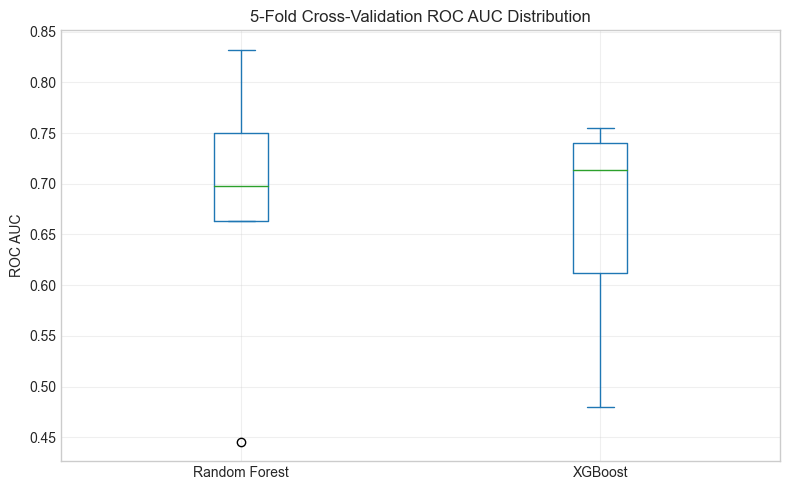

In [77]:
# Box plot of cross-validation scores
plt.figure(figsize=(8, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.plot(kind='box', figsize=(8, 5))
plt.title("5-Fold Cross-Validation ROC AUC Distribution")
plt.ylabel("ROC AUC")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 12. Summary and Conclusion

### Key Findings

1. **Data Characteristics**: The wafer dataset contains 590 sensor features with significant sparsity. After preprocessing, approximately 116 zero-variance features were removed, and missing values were imputed using KNN Imputer.

2. **Class Imbalance**: The dataset exhibits substantial class imbalance with approximately 94% non-faulty wafers and 6% faulty wafers. This was accounted for during model evaluation by focusing on ROC AUC and F1-score rather than accuracy alone.

3. **Sensor Importance**: Analysis revealed that only a subset of sensors contribute meaningfully to fault detection. PCA showed that 95% of the variance could be explained by significantly fewer components than the original feature count.

4. **Clustering Approach**: The KMeans clustering step (from the original project) segments the data into distinct groups, allowing specialized models for each cluster. This approach can capture different fault patterns across wafer subgroups.

5. **Model Performance**: Both Random Forest and XGBoost demonstrated strong performance on this binary classification task. The per-cluster training approach from the original project enables fine-grained model selection based on data characteristics within each cluster.

### Recommendations for Future Work

- Handling class imbalance through SMOTE or class weight adjustments could improve recall for faulty wafers.
- Dimensionality reduction (PCA or feature selection) before model training may improve generalization.
- Additional models such as Gradient Boosting, LightGBM, or Neural Networks could be explored.
- Hyperparameter tuning with a wider search space using RandomizedSearchCV could yield better results.
- The clustering-based approach could be extended with more sophisticated clustering algorithms.